## **Plantilla**

In [86]:
import pandas as pd

ruta = "https://raw.githubusercontent.com/VillaltaE/netflix_churn/refs/heads/main/netflix_customer_churn.csv"
df = pd.read_csv(ruta)

model_cols = [
    "subscription_type",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day",
    "payment_method"
]

X = df[model_cols]
y = df["churned"]

X.head(), y.value_counts(normalize=True)


(  subscription_type  watch_hours  last_login_days  monthly_fee  \
 0             Basic        14.73               29         8.99   
 1          Standard         0.70               19        13.99   
 2          Standard        16.32               10        13.99   
 3           Premium         4.51               12        17.99   
 4          Standard         1.89               13        13.99   
 
    number_of_profiles  avg_watch_time_per_day payment_method  
 0                   1                    0.49      Gift Card  
 1                   5                    0.03      Gift Card  
 2                   2                    1.48         Crypto  
 3                   2                    0.35         Crypto  
 4                   2                    0.13         Crypto  ,
 churned
 1    0.503
 0    0.497
 Name: proportion, dtype: float64)

## **Importar lo necesario**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier as RandomForest
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt



## **Definir columnas por tipo**



In [88]:
categorical_cols = ["subscription_type","payment_method"]
numeric_cols = [
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day"
]


## **Crear el preprocesador**

In [89]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop='first', handle_unknown="ignore"), categorical_cols),
        ("num", RobustScaler(), numeric_cols)
    ],
    remainder='passthrough'
)


## **Train/Validation/Test split (80/20)**


In [90]:
X_, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [91]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [92]:
X_train.shape, X_test.shape

((4000, 7), (1000, 7))

# **Armar el pipeline**

In [93]:
clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForest(max_depth=5))
])

## **Entrenar**

In [94]:
clf.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['subscription_type',
                                                   'payment_method']),
                                                 ('num', RobustScaler(),
                                                  ['watch_hours',
                                                   'last_login_days',
                                                   'monthly_fee',
                                                   'number_of_profiles',
                                                   'avg_watch_time_per_day'])])),
                ('model', RandomForestClassifier(max_depth=5))])

### Validación del modelo a partir de un conjunto de datos

In [95]:
y_val_pred = clf.predict(X_val)

### Reporte de métricas de clasificación

In [96]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.97      0.92      0.95       497
           1       0.93      0.98      0.95       503

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



### Matriz de Confusión

In [97]:
matriz = confusion_matrix(y_val, y_val_pred)

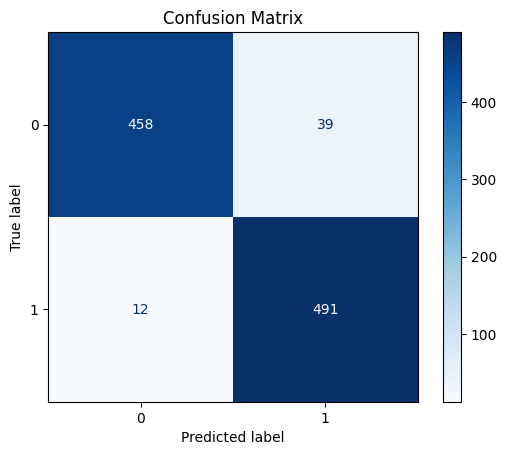

In [98]:
vis_confusion = ConfusionMatrixDisplay(confusion_matrix=matriz)
vis_confusion.plot(cmap='Blues');
plt.title('Confusion Matrix')

plt.show()

### Curva ROC

In [99]:
print(roc_curve(y_val, y_val_pred))

(array([0.        , 0.07847082, 1.        ]), array([0.        , 0.97614314, 1.        ]), array([inf,  1.,  0.]))


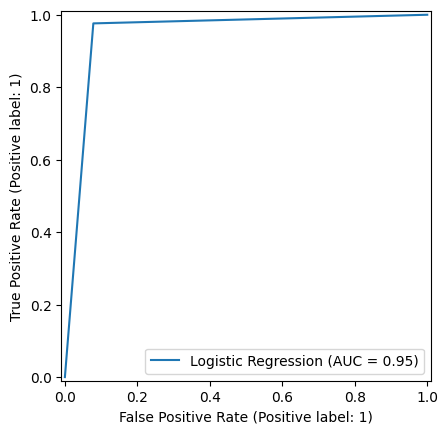

In [100]:
RocCurveDisplay.from_predictions(y_val,y_val_pred,name='Logistic Regression');

In [101]:
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_auc_score

In [102]:
#Gráfico alternativo de la curva ROC
# Generar un predictor sin habilidad
ns_probs = [0 for _ in range(len(y_test))]
# Calculo de la métrica auc
ns_auc = roc_auc_score(y_val, ns_probs)
lr_auc = roc_auc_score(y_val, y_val_pred)

# Cáculo de la curva roc
ns_fpr, ns_tpr, t = roc_curve(y_val, ns_probs)
lr_fpr, lr_tpr, t = roc_curve(y_val, y_val_pred)

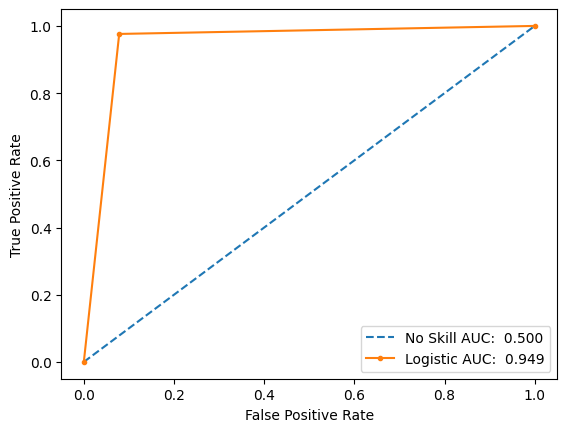

In [103]:
#Gráfico de la curva ROC
plt.plot(ns_fpr, ns_tpr, linestyle='--', label=f'No Skill AUC: {ns_auc: .3f}')
plt.plot(lr_fpr, lr_tpr, marker='.', label=f'Logistic AUC: {lr_auc: .3f}')
# Etiquetas de los ejes
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Mostrar la leyenda
plt.legend()
# Mostrar el gráfico
plt.show()

### Curva Precisión Sensibilidad

In [104]:
from sklearn.metrics import PrecisionRecallDisplay

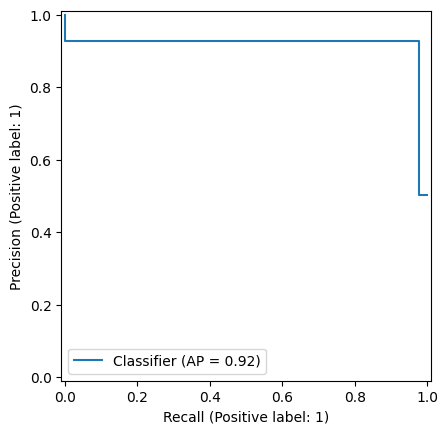

In [105]:
PrecisionRecallDisplay.from_predictions(y_val, y_val_pred);

In [106]:
from sklearn.metrics import precision_recall_curve

In [107]:
#Cálculo de las métricas recall y precisión
lr_precision, lr_recall, _ = precision_recall_curve(y_val, y_val_pred)
av_pre_score = round(average_precision_score(y_val, y_val_pred),3)
no_skill = len(y_val[y_val==1]) / len(y_val)


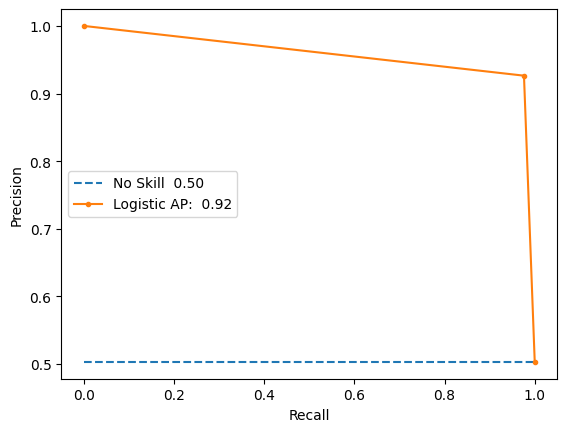

In [108]:
#Gŕafico de curva precision sensibilidad
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label=f'No Skill {no_skill: .2f}')
plt.plot(lr_recall, lr_precision, marker='.', label= f'Logistic AP: {av_pre_score: .2f}')

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.legend()

plt.show()


### Interpretación de las métricas y gráficos

### Exactitud

In [109]:
from sklearn.metrics import precision_score, recall_score

In [110]:
print(f'La exactitud del modelo con los datos de validación es: {accuracy_score(y_val, y_val_pred)}')

La exactitud del modelo con los datos de validación es: 0.949


### Precisión

In [111]:
print(f'La precisión del modelo con los datos de validación es: {precision_score(y_val, y_val_pred)}')

La precisión del modelo con los datos de validación es: 0.9264150943396227


### Sensibilidad

In [112]:
print(f'La sensibilidad del modelo con los datos de validación es: {recall_score(y_val, y_val_pred)}')

La sensibilidad del modelo con los datos de validación es: 0.9761431411530815


### Validación del modelo a partir de validación cruzada

In [113]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate

In [114]:
#Separamos las columnas predictoras y la que va a ser predecida
_X = df[model_cols]

_y = df['churned']

In [115]:
_X.columns

Index(['subscription_type', 'watch_hours', 'last_login_days', 'monthly_fee',
       'number_of_profiles', 'avg_watch_time_per_day', 'payment_method'],
      dtype='object')

### **Armar el pipeline para la validación cruzada**

In [116]:
#Creamos el objeto skfold que se encargará de la validación cruzada
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [117]:
cross_val_random = cross_validate(clf, _X, _y, cv=skfold, scoring=['precision','recall'])

In [118]:
cross_val_random

{'fit_time': array([0.36126137, 0.33141041, 0.37839985, 0.52279687, 0.51996088]),
 'score_time': array([0.02460361, 0.02829027, 0.04116082, 0.03258204, 0.03581333]),
 'test_precision': array([0.93945312, 0.91762452, 0.93269231, 0.91028037, 0.90996169]),
 'test_recall': array([0.95626243, 0.95228628, 0.96421471, 0.96819085, 0.944334  ])}

In [119]:
print(f'La media de la métrica precisión en la validación cruzada es : \
{round(cross_val_random['test_precision'].mean(),2)} ± {round(cross_val_random['test_precision'].std(),2)}\
')

La media de la métrica precisión en la validación cruzada es : 0.92 ± 0.01


In [120]:
print(f'La media de la métrica sensibilidad en la validación cruzada es: \
{round(cross_val_random['test_recall'].mean(),2)} ± {round(cross_val_random['test_recall'].std(),2)}\
        ')

La media de la métrica sensibilidad en la validación cruzada es: 0.96 ± 0.01        


## **Evaluar**

In [121]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      0.92      0.95       497
           1       0.93      0.98      0.95       503

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



#### Matriz de confusión

In [122]:
print(confusion_matrix(y_test, y_pred))

[[458  39]
 [ 12 491]]


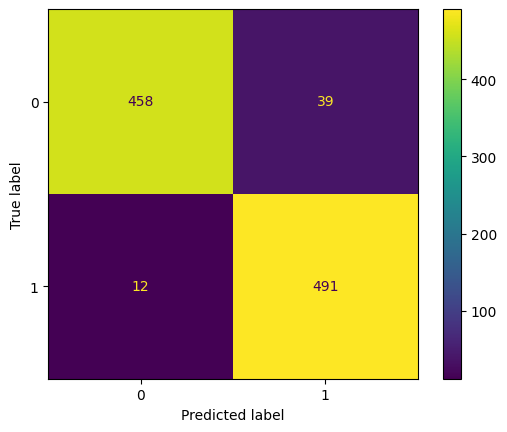

In [123]:
visualizacion = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
visualizacion.plot()

### Exactitud

In [124]:
print(f'La precision del modelo es:{accuracy_score(y_test, y_pred)}')

La precision del modelo es:0.949


### Precisión

In [125]:
from sklearn.metrics import precision_score, recall_score

In [126]:
print(f'La precisión del modelo con los datos de prueba: {precision_score(y_test, y_pred)}') 

La precisión del modelo con los datos de prueba: 0.9264150943396227


### Sensibilidad

In [127]:
print(f'La sensibilidad del modelo con los datos de prueba: {recall_score(y_test, y_pred)}') 

La sensibilidad del modelo con los datos de prueba: 0.9761431411530815


### Curva ROC

In [128]:
print(roc_curve(y_test, y_pred))

(array([0.        , 0.07847082, 1.        ]), array([0.        , 0.97614314, 1.        ]), array([inf,  1.,  0.]))


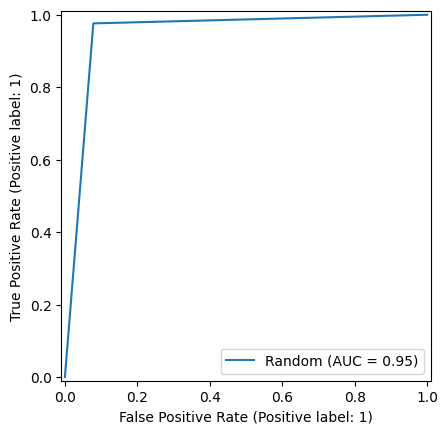

In [129]:
RocCurveDisplay.from_predictions(y_test,y_pred,name='Random');

#### La precisión del modelo de 0.99 indica que esta sobreajustado (overfittiing)

## **Probabilidades / API**

In [130]:
#Probabilidad de churn=1
y_proba = clf.predict_proba(X_test)[:, 1]
y_proba[:15]


array([0.0071506 , 0.87451842, 0.43384274, 0.91695382, 0.87866018,
       0.92429561, 0.83643223, 0.98636284, 0.52621615, 0.48011126,
       0.02997679, 0.20852961, 0.22112722, 0.05140389, 0.01540447])

## **Función de predicción**

In [131]:
def predict_cliente(input_dict):
    import pandas as pd

    df_input = pd.DataFrame([input_dict])

    proba = clf.predict_proba(df_input)[0, 1]
    pred = "Va a cancelar" if proba >= 0.5 else "Va a continuar"

    return {
        "prevision": pred,
        "probabilidad": round(float(proba), 3)
    }


## **Probar con un cliente / Manual**

In [132]:
cliente_ejemplo = {
    "subscription_type": "Standard",
    "watch_hours": 17,
    "last_login_days": 6,
    "monthly_fee": 7,
    "number_of_profiles": 4,
    "avg_watch_time_per_day": 0.29,
    "payment_method": "Paypal"

}

print(f'El resultado del modelo es:{predict_cliente(cliente_ejemplo)}')


El resultado del modelo es:{'prevision': 'Va a continuar', 'probabilidad': 0.329}


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
